In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

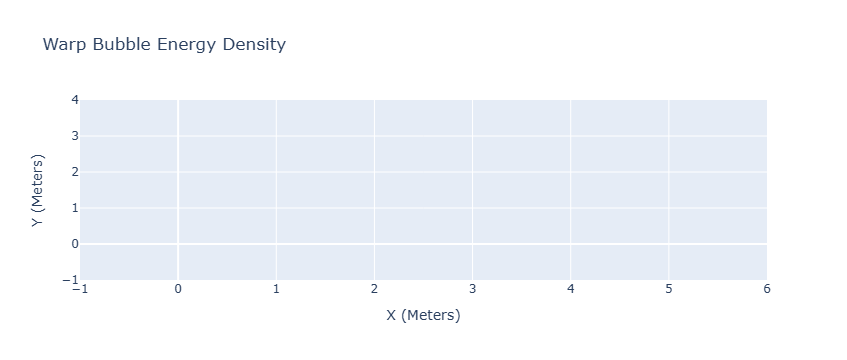

In [9]:
import torch
import plotly.graph_objects as go
import numpy as np

from core.metrics.alcubierre import get_alcubierre_metric
from core.solver.energy import get_energy_tensor
from core.visualizer.slicing import get_2d_slice
from core.utils import get_best_device

# Setup
device = get_best_device()
grid_size = (1, 64, 64, 64)
grid_scale = (0.1, 0.5, 0.5, 0.5)
world_center = (0.0, 16.0, 16.0, 16.0)

# Create a warp bubble
metric = get_alcubierre_metric(
    grid_size=grid_size,
    world_center=world_center,
    v=1.5,                          # 1.5x speed of light
    R=6.0,                          # bubble radius
    sigma=2.0,                       # wall thickness
    grid_scale=grid_scale,
    device=device
)

# Calculate energy
energy = get_energy_tensor(metric)

# Visualize as interactive 2D slice
energy_slice = get_2d_slice(energy, component=(0, 0), slice_plane='xy')

# Create coordinate axes (1-based indexing to match core implementation)
x_coords = (np.arange(1, grid_size[1] + 1) * grid_scale[1]) - world_center[1]
y_coords = (np.arange(1, grid_size[2] + 1) * grid_scale[2]) - world_center[2]

fig = go.Figure(data=go.Heatmap(
    z=energy_slice.T, x=x_coords, y=y_coords,
    colorscale='RdBu', zmid=0,
    colorbar=dict(title="Energy Density")
))
fig.update_layout(
    title="Warp Bubble Energy Density",
    xaxis_title="X (Meters)", yaxis_title="Y (Meters)"
)
fig.show()